# 06 — The flash/onsight ladder, and when 9b goes first try

Notebook 05 runs two tests on the female ladder: the tempting one, which hides a
single rung and crowns whichever shape predicts it best, and the harder one,
which makes every method predict five rungs it never saw. The first test picks a
shape that the second test demotes to seventh of ten.

This notebook runs the same pair on a third ladder — **the hardest grade climbed
first try** — and gets the same reversal a third time, from a different winner.

Three things about this ladder are different, and all three are properties of
the record rather than choices:

- **It mixes two styles.** *Onsight* means no prior information at all; *flash*
  allows beta. A flash is the easier of the two, so merging them measures two
  things with one number. They were reported separately for most of this history
  and have blurred in recent years, and splitting them now would leave two series
  too short to say anything about. Read the ladder as "hardest grade climbed
  first try", and treat any flash rung as a **lower bound** on what an onsight at
  that grade would have needed.
- **It has a hole at 8a+.** No first flash or onsight of an 8a+ is recorded, so
  that rung is absent rather than guessed. Everything below indexes on *position
  on the grade scale*, not on row number, so 8a sits at step 3 and 8b at step 5
  with the gap preserved.
- **Its first two rungs share a date.** Captain Crochet (7b+) and La Polka des
  Ringards (7c) are both recorded as "1982", both by Patrick Edlinger. A
  year-only date anchors to 1 January, so the two land on the same day and the
  ladder's first gap is exactly zero.

The open questions are **9b first try** (one step past the data) and **9b+** (two
steps). Only the one-step question gets tested.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from sportgradehistory import config
from sportgradehistory.flash_milestones import (
    MILESTONE_START, MISSING, crosscheck, flash_ladder, missing_rungs,
    ordering_notes)
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal

BASE = french_ordinal(MILESTONE_START)                  # 7b+
LADDER = list(FRENCH_SCALE[BASE:BASE + 13])             # 7b+ … 9b+

lad = flash_ladder()
ORIGIN = lad["year_frac"].iloc[0]                       # Captain Crochet, 1982.0
lad = lad.assign(months=(lad["year_frac"] - ORIGIN) * 12)

lad.to_csv(config.PROCESSED_DIR / "flash_milestones.csv", index=False)
print(lad[["grade", "route", "climber", "crag", "country", "ascent",
           "date_precision", "steps"]].to_string(index=False))
print(f"\nmissing rungs: {', '.join(missing_rungs(lad))} — "
      f"{MISSING['8a+']}")
print("note the step column: 8a is step 3 and 8b is step 5, because 8a+ is absent")

grade                 route              climber          crag country     ascent date_precision  steps
  7b+       Captain Crochet     Patrick Edlinger         Buoux     FRA 1982-01-01           year      0
   7c La Polka des Ringards     Patrick Edlinger         Buoux     FRA 1982-01-01           year      1
  7c+               Pol Pot        Jerry Moffatt  Verdon Gorge     FRA 1984-01-01           year      2
   8a              Samizdat Antoine Le Menestrel         Cimai     FRA 1987-01-01           year      3
   8b  Liaisons Dangereuses        Elie Chevieux Les Calanques     FRA 1993-01-01           year      5
  8b+      Massey Fergusson        Elie Chevieux     Calanques     FRA 1995-01-01           year      6
   8c          White Zombie        Yuji Hirayama      Baltzola     ESP 2004-10-06            day      7
  8c+         Bizi Euskaraz       Patxi Usobiaga       Etxauri     ESP 2007-12-11            day      8
   9a        Estado Critico           Alex Megos       Siurana  

## Does the scrape agree with the table?

The ladder comes from outside this repository, so every claim it makes that the
scrape *can* check is checked. The site records each route's first ascent, not
the first flash of it, so climber and date will often differ by design — the
column that has to agree is the **grade**.

In [2]:
check = crosscheck()
print(check[["grade", "route", "site_name", "site_grade", "grade_agrees",
             "site_fa_climber", "site_fa_date", "is_own_fa"]].to_string(index=False))

carried = check["grade_agrees"].notna()
print(f"\n{int(check.loc[carried, 'grade_agrees'].sum())}/{int(carried.sum())} routes "
      f"the site carries agree on grade; {int((~carried).sum())} are not in the "
      "scrape at all.")
print(f"{int(check['is_own_fa'].sum())} of the ten are the climber's own first ascent.")

grade                 route               site_name site_grade grade_agrees          site_fa_climber  site_fa_date is_own_fa
  7b+       Captain Crochet                     NaN        NaN         None                      NaN           NaN      None
   7c La Polka des Ringards                     NaN        NaN         None                      NaN           NaN      None
  7c+               Pol Pot                     NaN        NaN         None                      NaN           NaN      None
   8a              Samizdat                Samizdat         8a         True     Antoine Le Menestrel          1987      True
   8b  Liaisons Dangereuses                     NaN        NaN         None                      NaN           NaN      None
  8b+      Massey Fergusson     Les Massey Ferguson        8b+         True            Elie Chevieux          1995      True
   8c          White Zombie            White Zombie         8c         True        Fernando Martinez 17th Oct 1996     False


**Every grade the scrape can check, it confirms.** The four it cannot are the
four oldest and easiest — Captain Crochet, La Polka des Ringards, Pol Pot and
Liaisons Dangereuses. That is exactly where this source thins out: it carries 23
routes at 7b+ and 41 at 7c, against 223 at 8b, because it is a record of
milestones rather than of crags.

**Three rungs are the climber's own first ascent**, and that is a caveat rather
than a coincidence. Samizdat, Massey Fergusson and Bizi Euskaraz are all
recorded by the site as first ascents by the same climber on the same date as
the milestone — meaning those routes were climbed first try *without having been
climbed before at all*, and the grade was therefore proposed by the person
claiming the milestone. Nobody had confirmed the difficulty in advance. The
other seven are repeats of routes already established and graded by someone else.

### The two 1982 ascents, and what the dates cannot settle

In [3]:
print(ordering_notes(lad).to_string(index=False))

lower_grade     lower_route lower_date upper_grade           upper_route upper_date kind  inversion_years  anchoring_artifact
        7b+ Captain Crochet       1982          7c La Polka des Ringards       1982  tie              0.0                True


Both 1982 rungs are year-only, so both anchor to 1 January and the gap between
7b+ and 7c is exactly **zero years**. Two grades in the same year is not
impossible — Edlinger did both, and they may well have been weeks apart — but
the record cannot order them or space them, so the ladder's first interval is an
artifact and is reported as one rather than quietly smoothed.

Its effect is confined to the early folds of the test below: by the time the
methods are predicting 8c and above, that gap has dropped out of every
"last three intervals" window.

## First, the tempting test

Six shapes, fitted to the first nine rungs (7b+ → 9a), each asked for the tenth.
The ladder is fitted **sideways** — grade on the x axis, time on the y — so a
prediction comes out as a date. Time is counted in months since Captain Crochet
(1 Jan 1982).

Train on 7b+ → 9a. Predict 9a+. Score against Super Crackinette, 10 Feb 2018.

In [4]:
def exp_model(g, a, b, k):
    return a * np.exp(b * g) + k


def log_model(g, a, b):
    return a * np.log(g + 1) + b


def build_models(x, y):
    # The same six shapes, fitted to whatever slice of the ladder is passed.
    out = {}
    for deg in (1, 2, 3, 4):
        out[f"Poly {deg}"] = (lambda g, k=np.polyfit(x, y, deg): np.polyval(k, g))
    log_b, log_a = np.polyfit(x, np.log(y + 1.0), 1)        # seed the optimiser
    p_exp, _ = curve_fit(exp_model, x, y, p0=(np.exp(log_a), log_b, -1.0),
                         maxfev=200000)
    out["Exponential"] = lambda g, p=p_exp: exp_model(g, *p)
    p_log, _ = curve_fit(log_model, x, y, p0=(100.0, 0.0), maxfev=200000)
    out["Logarithmic"] = lambda g, p=p_log: log_model(g, *p)
    return out


TOP = 10                                                    # 9a+, the last rung
train = lad[lad["steps"] < TOP]                             # 7b+ … 9a
x, y = train["steps"].to_numpy(float), train["months"].to_numpy(float)
actual_top = float(lad.loc[lad["steps"] == TOP, "months"].iloc[0])
models = build_models(x, y)

rows = []
for name, f in models.items():
    pred = float(f(float(TOP)))
    rows.append({
        "model": name,
        "9a+ predicted": ORIGIN + pred / 12,
        "miss (years)": (pred - actual_top) / 12,
        "abs_miss": abs(pred - actual_top) / 12,
    })
holdout = pd.DataFrame(rows).sort_values("abs_miss").reset_index(drop=True)

print(f"actual 9a+: Super Crackinette, {ORIGIN + actual_top / 12:.2f}\n")
print(holdout.drop(columns="abs_miss").round(2).to_string(index=False))

actual 9a+: Super Crackinette, 2018.11

      model  9a+ predicted  miss (years)
     Poly 4        2017.00         -1.11
     Poly 3        2019.72          1.61
     Poly 2        2020.87          2.76
Exponential        2022.07          3.96
     Poly 1        2013.83         -4.28
Logarithmic        2006.25        -11.86


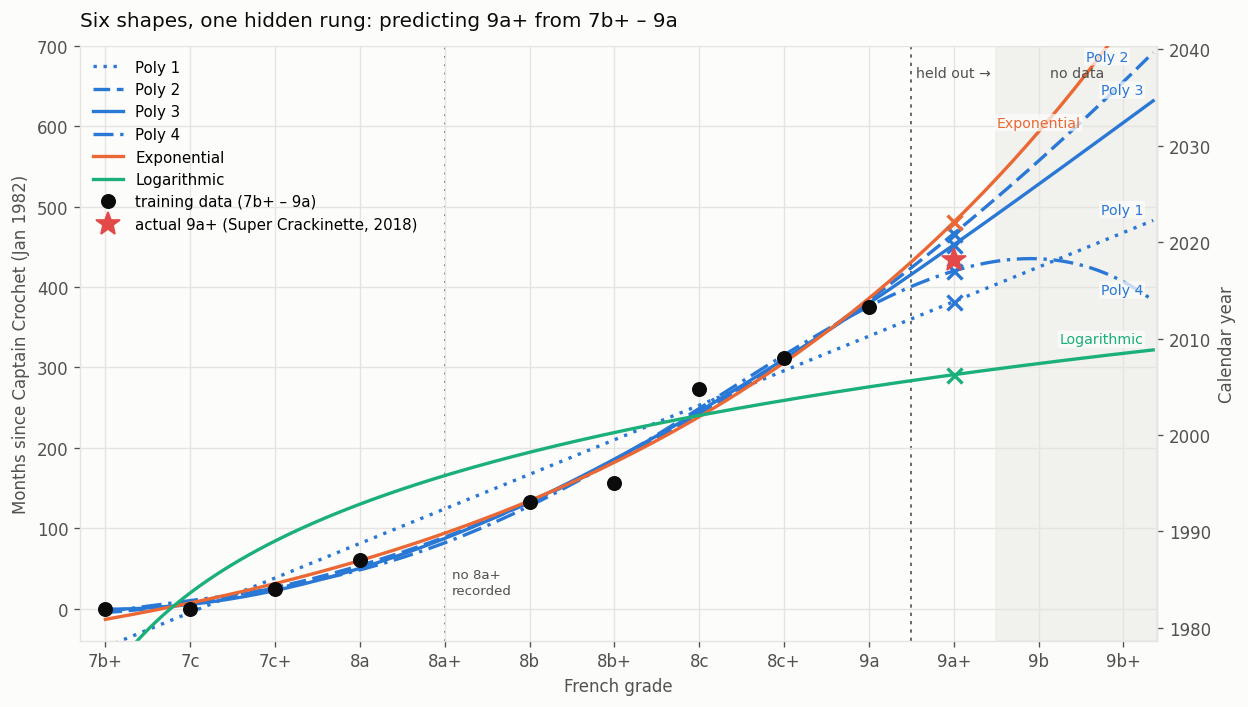

In [5]:
import matplotlib.pyplot as plt

PAPER, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"

# Polynomial degree is ordinal, so the four polys are one hue separated by dash
# pattern and direct labels; exp and log are different families and get their
# own hues.
STYLE = {
    "Poly 1":      (BLUE,   (0, (1, 2))),
    "Poly 2":      (BLUE,   (0, (5, 2))),
    "Poly 3":      (BLUE,   "-"),
    "Poly 4":      (BLUE,   (0, (6, 2, 1, 2))),
    "Exponential": (ORANGE, "-"),
    "Logarithmic": (AQUA,   "-"),
}
Y_TOP, GAP = 700, 27            # GAP: minimum vertical room between end labels

fig, ax = plt.subplots(figsize=(10.5, 6), dpi=120, facecolor=PAPER)
ax.set_facecolor(PAPER)
grid_g = np.linspace(0, 12.35, 420)

placed = []
for name, f in models.items():
    color, ls = STYLE[name]
    curve = f(grid_g)
    ax.plot(grid_g, curve, ls=ls, color=color, lw=2, label=name, zorder=2)
    ax.plot([TOP], [f(float(TOP))], "x", color=color, ms=9, mew=2, zorder=4)

    visible = np.flatnonzero(curve <= Y_TOP - 25)
    if not visible.size:
        continue
    j = visible[-1]
    ly = curve[j]
    while any(abs(ly - prev) < GAP for prev in placed):
        ly -= GAP
    placed.append(ly)
    ax.annotate(name, (grid_g[j], ly), xytext=(-6, 4), textcoords="offset points",
                fontsize=8.5, color=color, ha="right",
                bbox=dict(facecolor=PAPER, edgecolor="none", alpha=.75,
                          boxstyle="round,pad=0.12"))

ax.plot(x, y, "o", color=INK, ms=8, zorder=5, label="training data (7b+ – 9a)")
ax.plot([TOP], [actual_top], "*", color=RED, ms=15, zorder=6,
        label="actual 9a+ (Super Crackinette, 2018)")
ax.axvline(4, color=MUTED, lw=1, ls=(0, (1, 4)), zorder=1)
ax.text(4.08, 18, "no 8a+\nrecorded", fontsize=8, color=MUTED, linespacing=1.3)

ax.axvline(TOP - 0.5, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
ax.text(TOP - 0.44, Y_TOP - 38, "held out →", fontsize=8.5, color=MUTED)
ax.axvspan(10.5, 12.4, color=GRID, alpha=.45, zorder=0)
ax.text(11.45, Y_TOP - 38, "no data", fontsize=8.5, color=MUTED, ha="center")

ax.set_xticks(range(13)); ax.set_xticklabels(LADDER)
ax.set_xlim(-0.3, 12.4); ax.set_ylim(-40, Y_TOP)
ax.set_xlabel("French grade", color=MUTED)
ax.set_ylabel("Months since Captain Crochet (Jan 1982)", color=MUTED)

sec = ax.secondary_yaxis("right", functions=(lambda m: ORIGIN + m / 12,
                                             lambda yr: (yr - ORIGIN) * 12))
sec.set_ylabel("Calendar year", color=MUTED)
sec.tick_params(colors=MUTED); sec.spines["right"].set_color(GRID)

ax.grid(color=GRID, lw=.8, zorder=0)
ax.spines["top"].set_visible(False)
for side in ("left", "bottom", "right"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Six shapes, one hidden rung: predicting 9a+ from 7b+ – 9a",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "flash_validation_9aplus.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

**The quartic lands the hidden rung within thirteen months** — 2017.0 against
Super Crackinette's 2018.1 — with the cubic second at +1.6 years. On this
evidence the wiggliest shapes look best, which is precisely what happened on the
men's ladder in notebook 02 and on the women's in notebook 05.

Hold that thought.

## The real test: predict five rungs you never saw

Same test as the other two notebooks: train on the first *j* rungs only, predict
rung *j+1*, for j = 5 … 9. Five folds, each a genuine step past the end of what
the method was allowed to see. The same three **interval models** are scored
alongside the curves — repeat the last gap, average the last three, extend the
widening trend.

**One change is forced by the missing 8a+.** The interval models work on the
gaps between rungs, and the 8a → 8b gap spans *two* grades, not one. Every gap
is therefore measured **per grade step**: the six years from Samizdat (1987) to
Liaisons Dangereuses (1993) count as 3.0 years per step, not 6.0. On a gapless
ladder this changes nothing, and notebooks 02 and 05 are unaffected; here it
stops a two-grade jump being read as one ordinary step.

In [6]:
GV = lad["steps"].to_numpy(float)          # 0 (7b+) … 10 (9a+), with 4 absent
YV = lad["year_frac"].to_numpy(float)
MV = lad["months"].to_numpy(float)
NV = len(GV)
SHAPES = ["Poly 1", "Poly 2", "Poly 3", "Poly 4", "Exponential", "Logarithmic"]
INTERVALS = ["Repeat last interval", "Mean of last 3", "Widening trend"]


# fit `name` to the rungs given, and predict the date at `target` steps
def fit_on(name, gs, ms, ys, target):
    if name.startswith("Poly"):
        deg = int(name[-1])
        if len(gs) < deg + 1:
            return np.nan                  # underdetermined, not estimable
        return ORIGIN + float(np.polyval(np.polyfit(gs, ms, deg), target)) / 12
    if name == "Exponential":
        b, a = np.polyfit(gs, np.log(ms + 1.0), 1)
        p, _ = curve_fit(exp_model, gs, ms, p0=(np.exp(a), b, -1.0), maxfev=200000)
        return ORIGIN + float(exp_model(target, *p)) / 12
    if name == "Logarithmic":
        p, _ = curve_fit(log_model, gs, ms, p0=(100.0, 0.0), maxfev=200000)
        return ORIGIN + float(log_model(target, *p)) / 12
    # Gaps PER GRADE STEP, not per row: this ladder has no 8a+, so one row gap
    # spans two grades. np.diff(gs) is all ones on a gapless ladder.
    iv = np.diff(ys) / np.diff(gs)
    last, ahead = ys[-1], target - gs[-1]
    if name == "Repeat last interval":
        return last + iv[-1] * ahead
    if name == "Mean of last 3":
        return last + iv[-3:].mean() * ahead
    if name == "Widening trend":
        s, i = np.polyfit(range(len(iv)), iv, 1)
        return last + float(sum(s * (len(iv) + q) + i
                                for q in range(int(round(ahead)))))


roll = []
for name in SHAPES + INTERVALS:
    e = np.array([fit_on(name, GV[:j], MV[:j], YV[:j], GV[j]) - YV[j]
                  for j in range(5, NV)])
    roll.append({"method": name, "typical miss (y)": np.sqrt(np.nanmean(e ** 2)),
                 "bias (y)": np.nanmean(e), "worst (y)": np.nanmax(np.abs(e)),
                 "9b": fit_on(name, GV, MV, YV, 11.0),
                 "9b+": fit_on(name, GV, MV, YV, 12.0), "errors": e})

ens = np.array([np.mean([fit_on(m, GV[:j], MV[:j], YV[:j], GV[j]) for m in INTERVALS])
                - YV[j] for j in range(5, NV)])
roll.append({"method": "Ensemble of the 3 interval models",
             "typical miss (y)": np.sqrt(np.mean(ens ** 2)), "bias (y)": np.mean(ens),
             "worst (y)": np.max(np.abs(ens)),
             "9b": float(np.mean([fit_on(m, GV, MV, YV, 11.0) for m in INTERVALS])),
             "9b+": float(np.mean([fit_on(m, GV, MV, YV, 12.0) for m in INTERVALS])),
             "errors": ens})

ROLL = pd.DataFrame(roll).sort_values("typical miss (y)").reset_index(drop=True)
ROLL.drop(columns="errors").to_csv(
    config.PROCESSED_DIR / "flash_model_scores.csv", index=False)

print("Train on the first j rungs, predict the next, for j = 5 ... 9.")
print("The five folds predict:", ", ".join(lad["grade"].iloc[5:10]), "\n")
print(ROLL.drop(columns="errors").round(2).to_string(index=False))
print("\nper-fold error in years, + = predicted too late:")
for _, r in ROLL.iterrows():
    print(f"  {r['method']:<34} " + "  ".join(f"{v:+6.1f}" for v in r["errors"]))

print(f"\none hidden rung ranked the shapes: {' > '.join(holdout['model'])}")
print("five hidden rungs rank them:       "
      f"{' > '.join([m for m in ROLL['method'] if m in SHAPES])}")

Train on the first j rungs, predict the next, for j = 5 ... 9.
The five folds predict: 8b+, 8c, 8c+, 9a, 9a+ 

                           method  typical miss (y)  bias (y)  worst (y)      9b     9b+
                           Poly 2              3.17      0.76       5.36 2026.07 2033.47
                   Mean of last 3              3.33     -0.76       7.10 2022.56 2027.01
Ensemble of the 3 interval models              3.81     -0.07       7.04 2023.46 2029.02
                   Widening trend              3.91      0.93       6.26 2024.83 2032.16
                      Exponential              4.54      2.31       5.83 2026.84 2035.45
             Repeat last interval              4.67     -0.38       7.76 2022.99 2027.88
                           Poly 1              4.83     -4.28       7.63 2018.98 2022.75
                           Poly 3              5.11     -0.21       9.68 2023.66 2028.60
                           Poly 4              7.90      1.42      15.20 2020.85 2021.10

**The shape that won the first test finishes ninth of ten here.** Poly 4's
typical miss is **7.9 years**, and its five errors are +0.0, −8.8, **+15.2**,
+1.8, −1.1. The thirteen-month hit on 9a+ is the last number in a run containing
a fifteen-year miss. That is now the third ladder in this repository where the
single-rung test crowns a shape the five-rung test throws out — the men's
(notebook 02), the women's (notebook 05), and this one.

**This ladder is much easier to predict than the other two.** Typical misses run
3.2 to 9.9 years, against 5.3 to 19.4 on the female ladder. Eight of the ten
methods clear the six-year bar the other notebooks use, which means the bar
barely discriminates here — the interesting separation is at the top, where four
methods sit between 3.2 and 3.9 years.

**And for the first time, a curve wins.** Poly 2 scores 3.17 against the average
of the last three gaps at 3.33 — a margin of two months across five folds, which
is no margin at all. Treat them as tied rather than ranked; what matters is that
the quadratic and the simple arithmetic agree with each other, and that both beat
every wigglier shape.

**Every method walks into the same wall,** and it is the second fold: all ten
predict 8c far too early, by 5 to 11 years. Chevieux flashed 8b+ in 1995 and
nobody climbed 8c first try until Hirayama in 2004 — a **9.8-year gap**, the
longest in the ladder, and nothing before it hinted at one.

## The six shapes, one panel each

Ranked by the test that matters, with both scores on every panel.

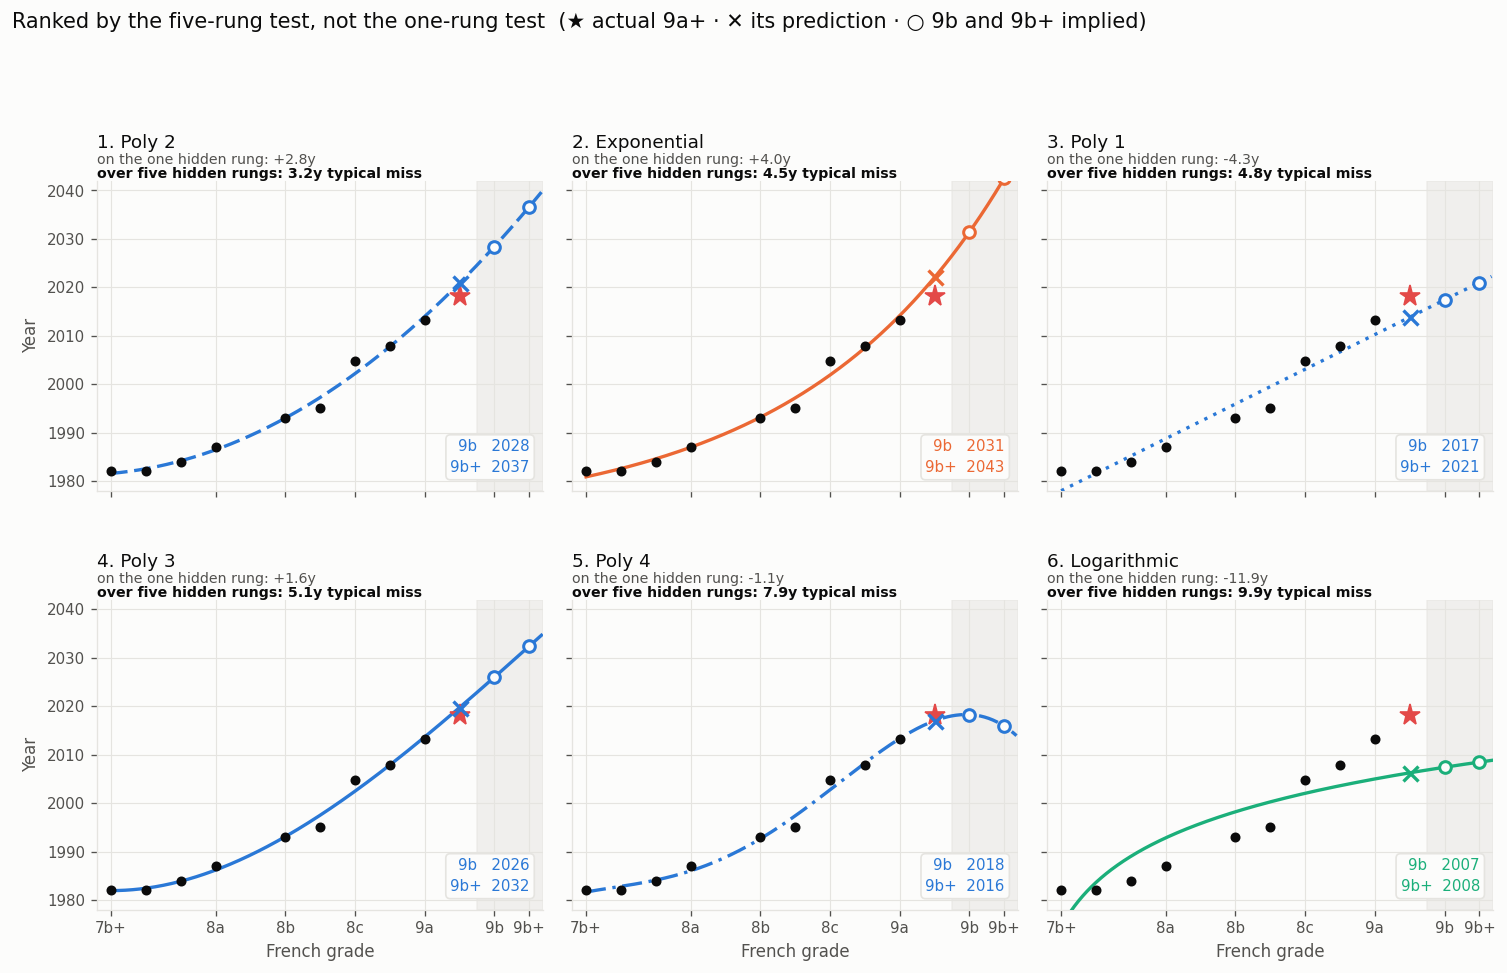

In [7]:
shape_scores = ROLL.set_index("method")
order = [m for m in ROLL["method"] if m in SHAPES]        # best-validating first
hold_by_model = holdout.set_index("model")

fig, axes = plt.subplots(2, 3, figsize=(12.6, 8.1), dpi=120, facecolor=PAPER,
                         sharex=True, sharey=True)

for rank, (name, ax) in enumerate(zip(order, axes.ravel()), start=1):
    f, (color, ls) = models[name], STYLE[name]
    ax.set_facecolor(PAPER)
    ax.axvspan(10.5, 12.4, color=GRID, alpha=.5, zorder=0)
    ax.grid(color=GRID, lw=.7, zorder=1)

    ax.plot(grid_g, ORIGIN + f(grid_g) / 12, ls=ls, color=color, lw=2, zorder=3)
    ax.plot(x, ORIGIN + y / 12, "o", color=INK, ms=5, zorder=5)
    ax.plot([TOP], [ORIGIN + actual_top / 12], "*", color=RED, ms=13, zorder=6)
    ax.plot([TOP], [ORIGIN + f(float(TOP)) / 12], "x", color=color, ms=9, mew=2,
            zorder=7)

    miss1 = hold_by_model.loc[name, "miss (years)"]
    typ = shape_scores.loc[name, "typical miss (y)"]
    ax.text(0, 1.105, f"{rank}. {name}", transform=ax.transAxes,
            fontsize=11, color=INK)
    ax.text(0, 1.055, f"on the one hidden rung: {miss1:+.1f}y",
            transform=ax.transAxes, fontsize=8.5, color=MUTED)
    ax.text(0, 1.010, f"over five hidden rungs: {typ:.1f}y typical miss",
            transform=ax.transAxes, fontsize=8.5, color=INK, fontweight="bold")

    for step in (11, 12):
        ax.plot([step], [ORIGIN + f(float(step)) / 12], "o", mfc=PAPER, mec=color,
                ms=7, mew=1.8, zorder=6)
    ax.text(0.97, 0.05,
            f"9b   {ORIGIN + f(11.) / 12:.0f}\n9b+  {ORIGIN + f(12.) / 12:.0f}",
            transform=ax.transAxes, fontsize=9, color=color, ha="right", va="bottom",
            linespacing=1.5,
            bbox=dict(facecolor=PAPER, edgecolor=GRID, boxstyle="round,pad=0.3"))

    for side in ("top", "right"): ax.spines[side].set_visible(False)
    for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

axes[0][0].set_xticks([0, 3, 5, 7, 9, 11, 12])
axes[0][0].set_xticklabels([LADDER[i] for i in (0, 3, 5, 7, 9, 11, 12)])
axes[0][0].set_xlim(-0.4, 12.4); axes[0][0].set_ylim(1978, 2042)
for ax in axes[:, 0]:
    ax.set_ylabel("Year", color=MUTED)
for ax in axes[1]:
    ax.set_xlabel("French grade", color=MUTED)

fig.suptitle("Ranked by the five-rung test, not the one-rung test  "
             "(★ actual 9a+ · ✕ its prediction · ○ 9b and 9b+ implied)",
             color=INK, fontsize=12.5, x=0.005, ha="left", y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.93), h_pad=3.2)
plt.savefig(config.FIGURES_DIR / "flash_model_panels.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

Read the two numbers at the top of each panel against each other:

- **Poly 2** is third on the hidden rung (+2.8) and first over five. It bends
  once, which is all this ladder's shape asks for.
- **Poly 4** is the reverse: the best single-rung score in the set (−1.1) and
  second-worst over five. It is the panel that should change your mind about the
  first chart.
- **Poly 1** is the only shape biased consistently early (−4.3 years on average).
  A straight line through a ladder that has been slowing down will always arrive
  ahead of schedule.
- **Logarithmic** is last again, and for the same reason as on the other two
  ladders: it flattens towards a ceiling that this history has not reached.

## So when does 9b go first try?

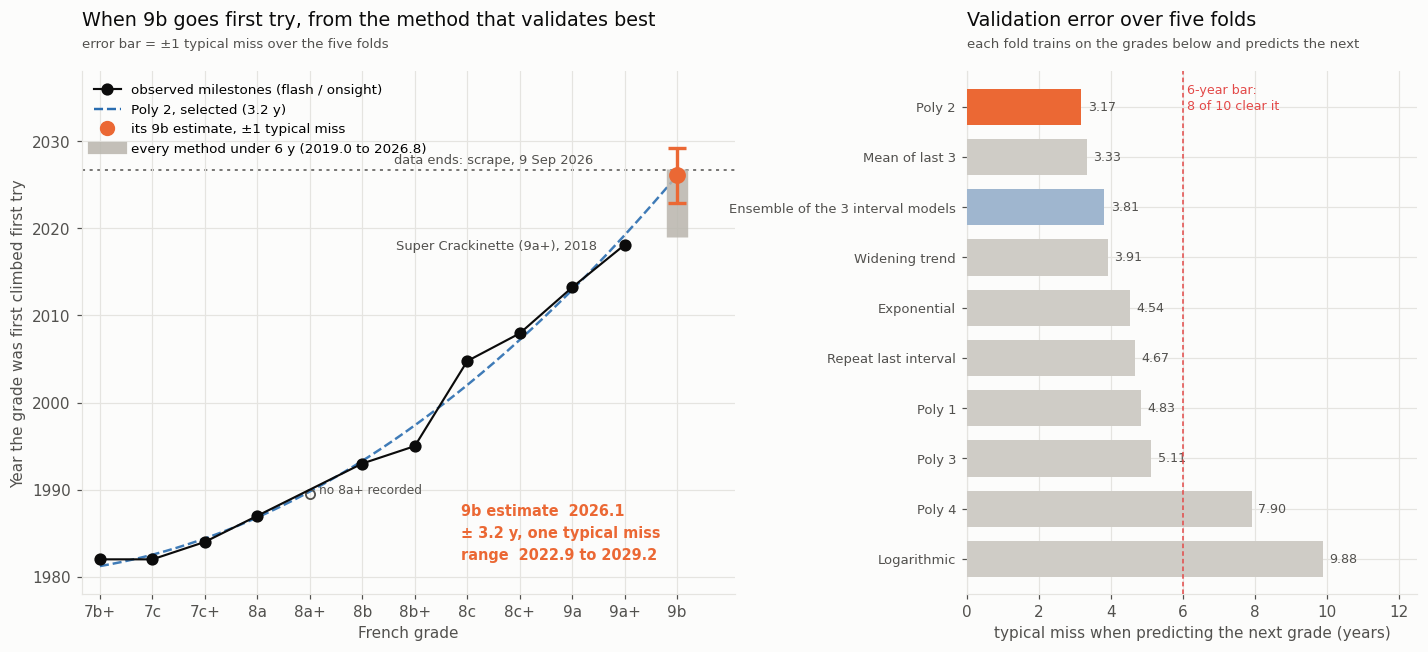

In [8]:
from matplotlib.lines import Line2D

SCRAPE = 2026 + (252 - 1) / 365.25          # the scrape date, 9 Sep 2026
CURVE_BLUE, GREY = "#2a6db0", "#b9b5ad"

BEST = ROLL.iloc[0]
best_name = BEST["method"]
best_9b = float(BEST["9b"])
best_miss = float(BEST["typical miss (y)"])
best_lo, best_hi = best_9b - best_miss, best_9b + best_miss
spread = ROLL[ROLL["typical miss (y)"] <= 6.0]["9b"].to_numpy(float)
gaps_name = "Mean of last 3"
gaps_miss = float(ROLL.set_index("method").loc[gaps_name, "typical miss (y)"])

fig = plt.figure(figsize=(13.2, 6.6), dpi=110, facecolor=PAPER)
grid = fig.add_gridspec(1, 2, width_ratios=[1.45, 1], wspace=.42,
                        left=.065, right=.985, top=.83, bottom=.11)
axL = fig.add_subplot(grid[0, 0])
axR = fig.add_subplot(grid[0, 1])
for ax in (axL, axR):
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

# --- left: the ladder, and where 9b lands ---
gg = np.linspace(0, 11, 320)
axL.plot(gg, [fit_on("Poly 2", GV, MV, YV, g) for g in gg], "--", color=CURVE_BLUE,
         lw=1.6, alpha=.9, zorder=2)
axL.plot(GV, YV, "-o", color=INK, lw=1.4, ms=7, zorder=5)
axL.axhline(SCRAPE, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
axL.text(5.6, SCRAPE + .7, "data ends: scrape, 9 Sep 2026", fontsize=8.5,
         color=MUTED, ha="left")
axL.vlines(11, spread.min(), spread.max(), color=GREY, lw=14, alpha=.85, zorder=3)
axL.errorbar([11], [best_9b], yerr=[best_miss], fmt="o", color=ORANGE, ms=10,
             elinewidth=2.2, capsize=6, capthick=2.2, zorder=6)
axL.annotate("Super Crackinette (9a+), 2018", (10, YV[-1]), xytext=(-150, -3),
             textcoords="offset points", fontsize=8.5, color=MUTED)
axL.annotate("no 8a+ recorded", (4, 1989.5), xytext=(6, 0),
             textcoords="offset points", fontsize=8, color=MUTED)
axL.plot([4], [1989.5], "o", mfc="none", mec=MUTED, ms=6, mew=1.2, zorder=4)
axL.text(.58, .06,
         f"9b estimate  {best_9b:.1f}\n"
         f"± {best_miss:.1f} y, one typical miss\n"
         f"range  {best_lo:.1f} to {best_hi:.1f}",
         transform=axL.transAxes, fontsize=9.5, color=ORANGE,
         fontweight="bold", va="bottom", linespacing=1.6)

handles = [
    Line2D([], [], color=INK, marker="o", lw=1.4, ms=7,
           label="observed milestones (flash / onsight)"),
    Line2D([], [], color=CURVE_BLUE, ls="--", lw=1.6,
           label=f"Poly 2, selected ({best_miss:.1f} y)"),
    Line2D([], [], color=ORANGE, marker="o", lw=0, ms=9,
           label="its 9b estimate, ±1 typical miss"),
    Line2D([], [], color=GREY, lw=8, alpha=.85,
           label=f"every method under 6 y ({spread.min():.1f} to {spread.max():.1f})"),
]
axL.legend(handles=handles, frameon=False, fontsize=8.8, loc="upper left")
axL.set_xticks(range(12))
axL.set_xticklabels(LADDER[:12])
axL.set_xlim(-0.35, 12.1)
axL.set_ylim(1978, 2038)
axL.set_xlabel("French grade", color=MUTED)
axL.set_ylabel("Year the grade was first climbed first try", color=MUTED)
axL.set_title("When 9b goes first try, from the method that validates best",
              color=INK, fontsize=12.5, loc="left", pad=30)
axL.text(0, 1.045, "error bar = ±1 typical miss over the five folds",
         transform=axL.transAxes, fontsize=8.7, color=MUTED)

# --- right: why that method was chosen ---
order_r = ROLL.sort_values("typical miss (y)", ascending=False)
cols = [ORANGE if m == best_name else ("#9fb6cf" if "Ensemble" in m else "#cfccc6")
        for m in order_r["method"]]
axR.barh(range(len(order_r)), order_r["typical miss (y)"], color=cols, zorder=3,
         height=.72)
axR.set_yticks(range(len(order_r)))
axR.set_yticklabels(order_r["method"], fontsize=8.6, color=MUTED)
for i, v in enumerate(order_r["typical miss (y)"]):
    axR.text(v + .18, i, f"{v:.2f}", va="center", fontsize=8.3, color=MUTED)
axR.axvline(6.0, color=RED, lw=1, ls=(0, (3, 2)), zorder=4)
axR.text(6.12, len(order_r) - .55, "6-year bar:\n8 of 10 clear it", fontsize=8.3,
         color=RED, linespacing=1.3, va="top")
axR.set_xlim(0, 12.5)
axR.set_ylim(-.7, len(order_r) - .3)
axR.set_xlabel("typical miss when predicting the next grade (years)", color=MUTED)
axR.set_title("Validation error over five folds", color=INK, fontsize=12.5,
              loc="left", pad=30)
axR.text(0, 1.045, "each fold trains on the grades below and predicts the next",
         transform=axR.transAxes, fontsize=8.7, color=MUTED)

plt.savefig(config.FIGURES_DIR / "flash_arrival_9b.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

**9b first try in 2026, give or take three years — which means it is due now.**

The selected method is the quadratic, and the average of the last three gaps
(tied with it on score) says 2022.6. The two together put the first 9b flash
between **2022.6 and 2026.1**, and the scrape date is 9 September 2026. Every
method that clears the six-year bar puts it between **2019.0 and 2026.8** —
i.e. *all* of them say it is already due or overdue.

That is a stronger statement than either of the other two ladders produced, and
it comes with an obvious caveat: **the ladder has been stalled for 8.6 years.**
Super Crackinette was February 2018. The longest completed gap in this history
is the 9.8 years from Chevieux's 8b+ to Hirayama's 8c, so the current wait
becomes the longest on record in **late 2027** — and, as the folds show, a long
stall is exactly the event none of these methods can anticipate.

### Each method on its own panel, two grades out

The five best-scoring methods, one panel each, pushed **two** steps past Super
Crackinette: to 9b, and then to 9b+.

Curves are drawn across the whole ladder, because they are fitted through all
ten rungs. The interval models know only the gaps and step forward from 9a+, so
they are drawn as a projection with nothing behind them. The error bar at 9b is
the track record from the folds; the 9b+ marker is hollow because **nothing here
validates a two-step jump** — every fold predicted one grade ahead.

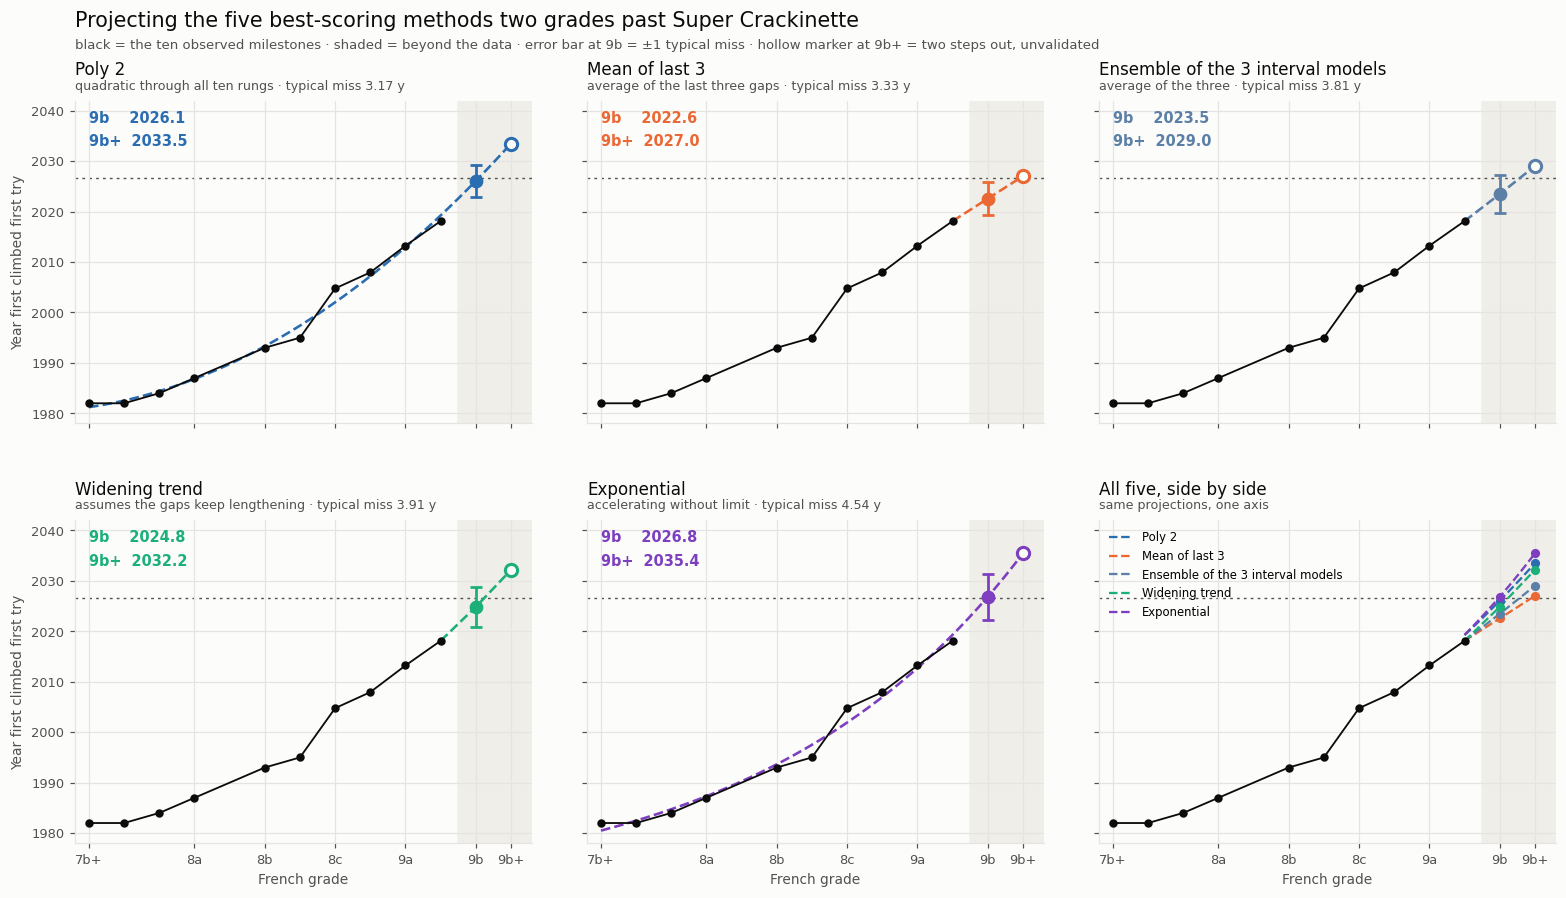

                           method  typical miss (y)      9b     9b+  implied gap
                           Poly 2              3.17 2026.07 2033.47         7.40
                   Mean of last 3              3.33 2022.56 2027.01         4.45
Ensemble of the 3 interval models              3.81 2023.46 2029.02         5.55
                   Widening trend              3.91 2024.83 2032.16         7.33
                      Exponential              4.54 2026.84 2035.45         8.61


In [9]:
def project(name, target):
    if name == "Ensemble of the 3 interval models":
        return float(np.mean([fit_on(m, GV, MV, YV, target) for m in INTERVALS]))
    return fit_on(name, GV, MV, YV, target)


SCORE = ROLL.set_index("method")["typical miss (y)"]
PANELS = [
    ("Poly 2", "#2a6db0", "quadratic through all ten rungs"),
    ("Mean of last 3", "#eb6834", "average of the last three gaps"),
    ("Ensemble of the 3 interval models", "#5b7fa6", "average of the three"),
    ("Widening trend", "#1baf7a", "assumes the gaps keep lengthening"),
    ("Exponential", "#7d3fbf", "accelerating without limit"),
]
PANELS = [(n, float(SCORE[n]), c, b) for n, c, b in PANELS]
TICKS = [0, 3, 5, 7, 9, 11, 12]
TICKLAB = [LADDER[i] for i in TICKS]
YLO, YHI = 1978, 2042

fig, axes = plt.subplots(2, 3, figsize=(14.4, 8.6), dpi=110, facecolor=PAPER,
                         sharex=True, sharey=True)
fig.subplots_adjust(left=.055, right=.99, top=.87, bottom=.085,
                    wspace=.12, hspace=.30)
for ax in axes.ravel():
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=8.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

for ax, (name, miss, color, blurb) in zip(axes.ravel(), PANELS):
    ax.axvspan(10.5, 12.6, color="#f0eee9", zorder=0)      # beyond the data
    ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
    ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)

    p11, p12 = project(name, 11.0), project(name, 12.0)
    if name in SHAPES:                                     # a curve through the data
        gg = np.linspace(0, 12, 280)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.7,
                zorder=3)
    else:                                                  # a forward projection only
        ax.plot([10, 11, 12], [YV[-1], p11, p12], "--", color=color, lw=1.7,
                zorder=3)
    ax.errorbar([11], [p11], yerr=[miss], fmt="o", color=color, ms=8,
                elinewidth=1.8, capsize=4, capthick=1.8, zorder=6)
    ax.plot([12], [p12], "o", mfc=PAPER, mec=color, mew=2, ms=8, zorder=6)

    ax.text(.03, .97, f"9b    {p11:.1f}\n9b+  {p12:.1f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9.5,
            color=color, fontweight="bold", linespacing=1.7)
    ax.set_title(name, color=INK, fontsize=11, loc="left", pad=17)
    ax.text(0, 1.035, f"{blurb} · typical miss {miss:.2f} y",
            transform=ax.transAxes, fontsize=8.3, color=MUTED)

ax = axes.ravel()[5]                                       # all five together
ax.axvspan(10.5, 12.6, color="#f0eee9", zorder=0)
ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)
for name, miss, color, _ in PANELS:
    p11, p12 = project(name, 11.0), project(name, 12.0)
    if name in SHAPES:
        gg = np.linspace(10, 12, 60)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.5,
                zorder=3)
    else:
        ax.plot([10, 11, 12], [YV[-1], p11, p12], "--", color=color, lw=1.5,
                zorder=3)
    ax.plot([11, 12], [p11, p12], "o", color=color, ms=5, zorder=5)
ax.set_title("All five, side by side", color=INK, fontsize=11, loc="left", pad=17)
ax.text(0, 1.035, "same projections, one axis", transform=ax.transAxes,
        fontsize=8.3, color=MUTED)
ax.legend(handles=[Line2D([], [], color=c, ls="--", lw=1.5, label=n)
                   for n, _, c, _ in PANELS],
          frameon=False, fontsize=7.6, loc="upper left")

for ax in axes.ravel():
    ax.set_xticks(TICKS)
    ax.set_xticklabels(TICKLAB)
    ax.set_xlim(-0.4, 12.6)
    ax.set_ylim(YLO, YHI)
for ax in axes[1]:
    ax.set_xlabel("French grade", color=MUTED, fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("Year first climbed first try", color=MUTED, fontsize=9)

fig.suptitle("Projecting the five best-scoring methods two grades past Super Crackinette",
             color=INK, fontsize=13.5, x=.055, ha="left", y=.965)
fig.text(.055, .925,
         "black = the ten observed milestones · shaded = beyond the data · "
         "error bar at 9b = ±1 typical miss · "
         "hollow marker at 9b+ = two steps out, unvalidated",
         fontsize=8.7, color=MUTED)
plt.savefig(config.FIGURES_DIR / "flash_projection_panels.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

print(pd.DataFrame([{"method": n, "typical miss (y)": m,
                     "9b": project(n, 11.0), "9b+": project(n, 12.0),
                     "implied gap": project(n, 12.0) - project(n, 11.0)}
                    for n, m, _, _ in PANELS]).round(2).to_string(index=False))

**The five agree on 9b within four and a half years and disagree about 9b+ by
eight.** The
same compounding as the other ladders, but milder, because this history is more
regular than either the men's or the women's.

## An independent check that fits nothing

The estimate above rests on one test of five folds. Here is a cross-check that
uses no curve and no gap model: how far the flash/onsight ladder trails the
**redpoint** ladder — the same grade, climbed with as many attempts as it takes.

In [10]:
red = pd.read_csv(config.PROCESSED_DIR / "milestones_as_consensus.csv")
red_yf = dict(zip(red["grade"], red["year_frac"]))
lag = lad.assign(redpoint=lad["grade"].map(red_yf))
lag["lag_years"] = lag["year_frac"] - lag["redpoint"]
lag = lag.dropna(subset=["redpoint"])
print(lag[["grade", "redpoint", "year_frac", "lag_years"]]
      .rename(columns={"year_frac": "first_try"}).round(1).to_string(index=False))

lv = lag["lag_years"].to_numpy()
red_9b = red_yf["9b"]
print(f"\nmedian lag {np.median(lv):.1f}y · mean of the last three {lv[-3:].mean():.1f}y "
      f"· lag at 9a+ {lv[-1]:.1f}y")
print(f"9b was redpointed in {red_9b:.1f}, so the lag puts the first 9b flash "
      f"between {red_9b + np.median(lv):.1f} and {red_9b + lv[-3:].mean():.1f}")

grade  redpoint  first_try  lag_years
   8b    1984.8     1993.0        8.2
  8b+    1985.0     1995.0       10.0
   8c    1987.0     2004.8       17.8
  8c+    1990.2     2007.9       17.7
   9a    1990.4     2013.2       22.8
  9a+    1996.0     2018.1       22.1

median lag 17.7y · mean of the last three 20.9y · lag at 9a+ 22.1y
9b was redpointed in 2008.7, so the lag puts the first 9b flash between 2026.4 and 2029.6


**The lag has widened steadily, and it pushes the estimate later.** The gap
between redpointing a grade and climbing one first try runs about 8 years at 8b,
10 at 8b+, and around 22 by 9a and 9a+. Applying the median lag to the 2008
redpoint of 9b gives **2026.4**; applying the mean of the last three gives
**2029.6**.

So this check lands on **2026–2030**, against **2022.6–2026.1** from the two
best-scoring models. They overlap only at the edges, and the disagreement is
informative rather than noise. The fitted and interval models extrapolate the
*flash ladder's own rhythm*, which has lately been a fairly steady 4–5 years per
grade. The lag model says that rhythm is not independent: first-try ascents
track redpoint ascents at a widening distance, and 9b was redpointed in 2008 by
one person on one route. Which is right depends on whether the limiting factor
is the climbers or the supply of routes at the grade suited to being flashed,
and this dataset cannot settle that.

Where they agree: **nobody should expect a 9b flash to be far away.** The
optimistic reading has it overdue already; the pessimistic reading has it before
2030.

## What this notebook supports, and what it does not

| | 9b first try | 9b+ first try |
| --- | --- | --- |
| Poly 2 (selected) | **2026.1** | 2033.5 |
| Its track record, ±1 typical miss | **2022.9 – 2029.2** | — |
| Average of the last 3 gaps (tied on score) | 2022.6 | 2027.0 |
| All methods under the six-year bar | 2019.0 – 2026.8 | 2021.1 – 2035.5 |
| Lag behind the redpoint ladder | 2026 – 2030 | not computable |
| **Read it as** | **due now, and overdue by 2030** | **untested** |

The caveats that travel with it:

- **Two styles in one series.** Flash and onsight are not the same achievement,
  and the ladder does not say which is which. Every rung is at best a lower
  bound on the onsight standard at that grade.
- **A hole at 8a+ and a tie at 1982.** Nine usable gaps from ten rungs, one of
  which is exactly zero and one of which spans two grades.
- **Three rungs are self-graded** — Samizdat, Massey Fergusson and Bizi Euskaraz
  were first ascents by the same climber, so the difficulty was proposed by the
  person claiming the milestone rather than confirmed beforehand.
- **No method is reliable to better than about three years**, by its own track
  record, and the top four are separated by less than one.
- **The 8.6-year stall since 2018 is the second-longest in this history** and is
  the kind of event every fold shows these methods cannot see coming.